# AAI-510 Assignment 3 — Seeing the Forest for the Trees

**Author:** Marco Gonzalez  
**Date:** June 2026  
**Course:** AAI-510 — Introduction to Artificial Intelligence

---

### Objective

Build and compare a **single Decision Tree** and a **Random Forest** classifier on the Home Credit Default Risk dataset, using no more than 20 features. Handle class imbalance, evaluate with metrics beyond accuracy, and explain performance differences.

### AI Disclosure

Claude Code (Anthropic) was used to assist with code structure and drafting analysis text. All feature selections, model interpretation, and conclusions were reviewed and validated by the author.

---
## 1. Setup and Data Preparation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('assignment/train_data.csv')
print(f"Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target distribution:\n{df['TARGET'].value_counts()}")
print(f"Imbalance ratio: {df['TARGET'].value_counts()[0] / df['TARGET'].value_counts()[1]:.1f}:1")

Dataset: 153,755 rows x 122 columns
Target distribution:
TARGET
0    141343
1     12412
Name: count, dtype: int64
Imbalance ratio: 11.4:1


---
## 2. Feature Selection (20 Variables)

The 20 features below were selected to cover diverse signal types — external credit scores, financial amounts, employment/demographic indicators, and behavioral flags — while keeping missingness manageable.

| # | Feature | Type | Rationale |
|---|---------|------|-----------|
| 1 | `EXT_SOURCE_1` | Continuous | External credit score (source 1) |
| 2 | `EXT_SOURCE_2` | Continuous | External credit score (source 2) — strongest predictor |
| 3 | `EXT_SOURCE_3` | Continuous | External credit score (source 3) |
| 4 | `DAYS_BIRTH` | Continuous | Client age (negative days from application) |
| 5 | `DAYS_EMPLOYED` | Continuous | Employment length |
| 6 | `DAYS_REGISTRATION` | Continuous | Days since ID registration |
| 7 | `DAYS_ID_PUBLISH` | Continuous | Days since last ID document change |
| 8 | `AMT_INCOME_TOTAL` | Continuous | Total income |
| 9 | `AMT_CREDIT` | Continuous | Loan credit amount |
| 10 | `AMT_ANNUITY` | Continuous | Loan annuity payment |
| 11 | `AMT_GOODS_PRICE` | Continuous | Price of goods for which loan is given |
| 12 | `REGION_POPULATION_RELATIVE` | Continuous | Normalized population of client region |
| 13 | `HOUR_APPR_PROCESS_START` | Discrete | Hour of application |
| 14 | `REGION_RATING_CLIENT` | Ordinal | Region rating (1-3) |
| 15 | `CNT_FAM_MEMBERS` | Discrete | Family member count |
| 16 | `DEF_30_CNT_SOCIAL_CIRCLE` | Discrete | Defaults in social circle (30 days) |
| 17 | `CODE_GENDER` | Binary | Gender (encoded) |
| 18 | `FLAG_OWN_CAR` | Binary | Owns a car |
| 19 | `FLAG_OWN_REALTY` | Binary | Owns real estate |
| 20 | `NAME_EDUCATION_TYPE` | Categorical | Education level (encoded) |

In [2]:
features = [
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH',
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'REGION_POPULATION_RELATIVE', 'HOUR_APPR_PROCESS_START',
    'REGION_RATING_CLIENT', 'CNT_FAM_MEMBERS', 'DEF_30_CNT_SOCIAL_CIRCLE',
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE'
]

data = df[features + ['TARGET']].copy()

# Encode categorical/binary string columns
le_cols = ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE']
encoders = {}
for col in le_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col].astype(str))
    encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Handle DAYS_EMPLOYED anomaly (365243 = pensioner flag)
data['DAYS_EMPLOYED'] = data['DAYS_EMPLOYED'].replace(365243, np.nan)

# Fill missing values with median
print(f"\nMissing values before imputation: {data.isnull().sum().sum():,}")
data = data.fillna(data.median(numeric_only=True))
print(f"Missing values after imputation: {data.isnull().sum().sum()}")
print(f"\nFinal dataset: {data.shape}")

CODE_GENDER: {'F': np.int64(0), 'M': np.int64(1)}
FLAG_OWN_CAR: {'N': np.int64(0), 'Y': np.int64(1)}
FLAG_OWN_REALTY: {'N': np.int64(0), 'Y': np.int64(1)}
NAME_EDUCATION_TYPE: {'Academic degree': np.int64(0), 'Higher education': np.int64(1), 'Incomplete higher': np.int64(2), 'Lower secondary': np.int64(3), 'Secondary / secondary special': np.int64(4)}

Missing values before imputation: 145,915
Missing values after imputation: 0

Final dataset: (153755, 21)


---
## 3. Train-Test Split and SMOTE Oversampling

The target is heavily imbalanced (~92% class 0 vs ~8% class 1). We apply **SMOTE** (Synthetic Minority Over-sampling Technique) on the training set only to balance classes, and evaluate with metrics beyond accuracy: **F1-score, precision, recall, AUC-ROC, and Average Precision**.

In [3]:
X = data.drop('TARGET', axis=1)
y = data['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train (original): {y_train.value_counts().to_dict()}")
print(f"Train (SMOTE):    {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Test:             {y_test.value_counts().to_dict()}")

Train (original): {0: 106007, 1: 9309}
Train (SMOTE):    {0: 106007, 1: 106007}
Test:             {0: 35336, 1: 3103}


---
## 4. Single Decision Tree

In [4]:
# Unpruned tree to show overfitting baseline
dt_full = DecisionTreeClassifier(random_state=42)
dt_full.fit(X_train_sm, y_train_sm)
print(f"Unpruned tree depth: {dt_full.get_depth()}, leaves: {dt_full.get_n_leaves()}")

# Pruned tree: constrain depth and leaf size to prevent overfitting
dt_pruned = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=100, random_state=42
)
dt_pruned.fit(X_train_sm, y_train_sm)
print(f"Pruned tree depth: {dt_pruned.get_depth()}, leaves: {dt_pruned.get_n_leaves()}")

Unpruned tree depth: 43, leaves: 16830


Pruned tree depth: 8, leaves: 190


### 4.1 Decision Tree Visualization

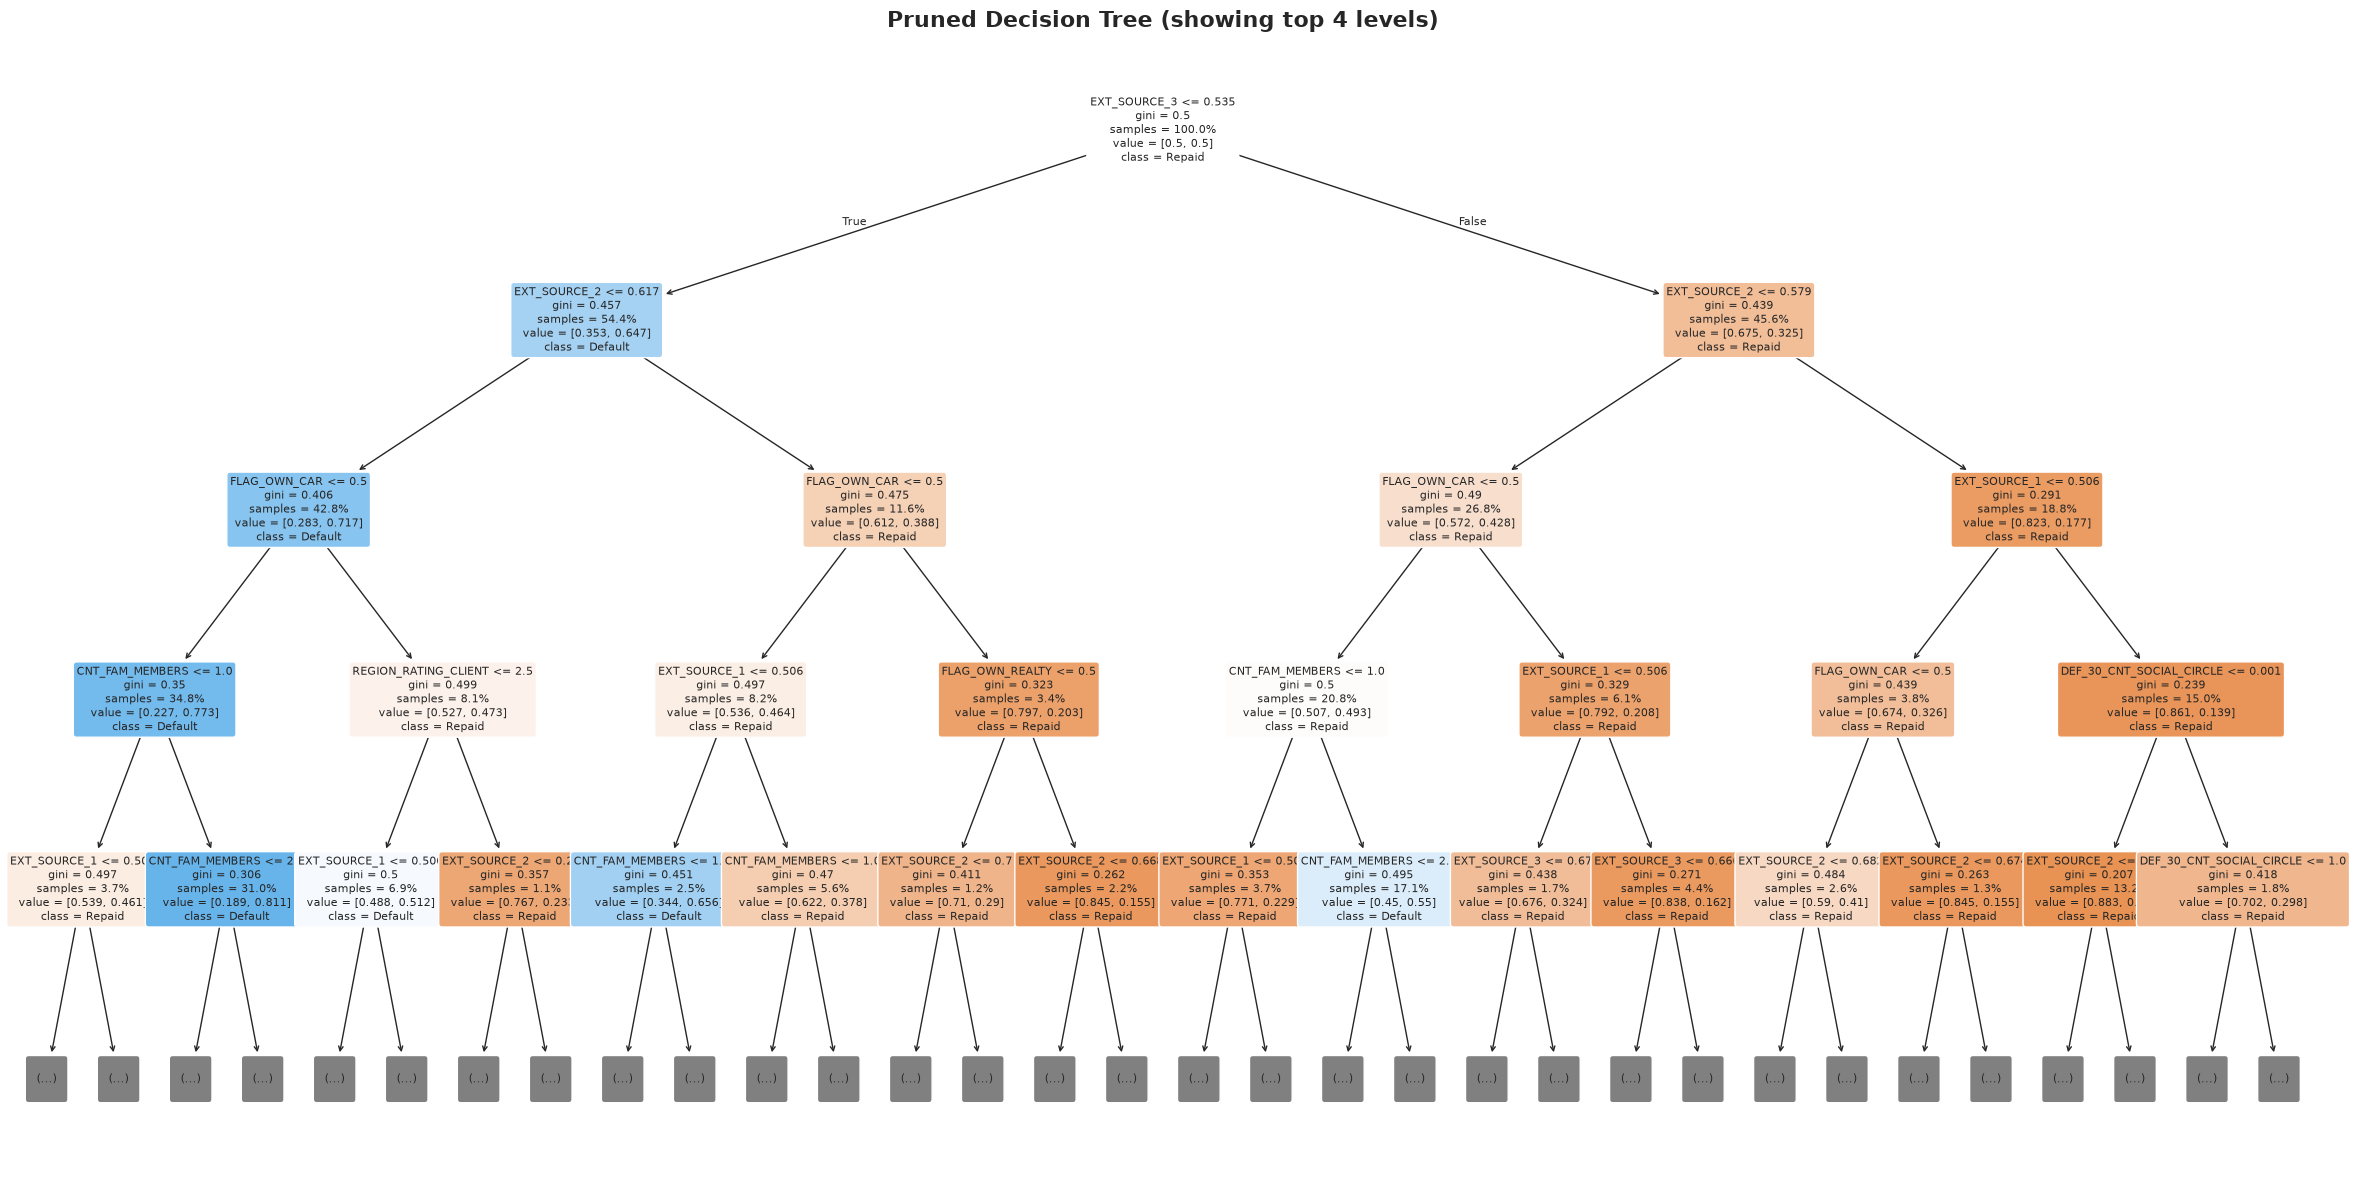

In [5]:
plt.figure(figsize=(24, 12))
plot_tree(dt_pruned, feature_names=features, class_names=['Repaid', 'Default'],
          filled=True, rounded=True, max_depth=4, fontsize=8, proportion=True)
plt.title('Pruned Decision Tree (showing top 4 levels)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Decision Tree Evaluation

In [6]:
y_pred_dt = dt_pruned.predict(X_test)
y_prob_dt = dt_pruned.predict_proba(X_test)[:, 1]

print("=== Decision Tree — Test Set Performance ===")
print(classification_report(y_test, y_pred_dt, target_names=['Repaid', 'Default']))
print(f"AUC-ROC:           {roc_auc_score(y_test, y_prob_dt):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_dt):.4f}")

=== Decision Tree — Test Set Performance ===
              precision    recall  f1-score   support

      Repaid       0.93      0.85      0.89     35336
     Default       0.13      0.25      0.17      3103

    accuracy                           0.80     38439
   macro avg       0.53      0.55      0.53     38439
weighted avg       0.86      0.80      0.83     38439

AUC-ROC:           0.6416
Average Precision: 0.1238


---
## 5. Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=50,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest — Test Set Performance ===")
print(classification_report(y_test, y_pred_rf, target_names=['Repaid', 'Default']))
print(f"AUC-ROC:           {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_prob_rf):.4f}")

=== Random Forest — Test Set Performance ===
              precision    recall  f1-score   support

      Repaid       0.93      0.87      0.90     35336
     Default       0.16      0.28      0.20      3103

    accuracy                           0.82     38439
   macro avg       0.55      0.57      0.55     38439
weighted avg       0.87      0.82      0.84     38439

AUC-ROC:           0.6753
Average Precision: 0.1376


### 5.1 Feature Importance — Random Forest

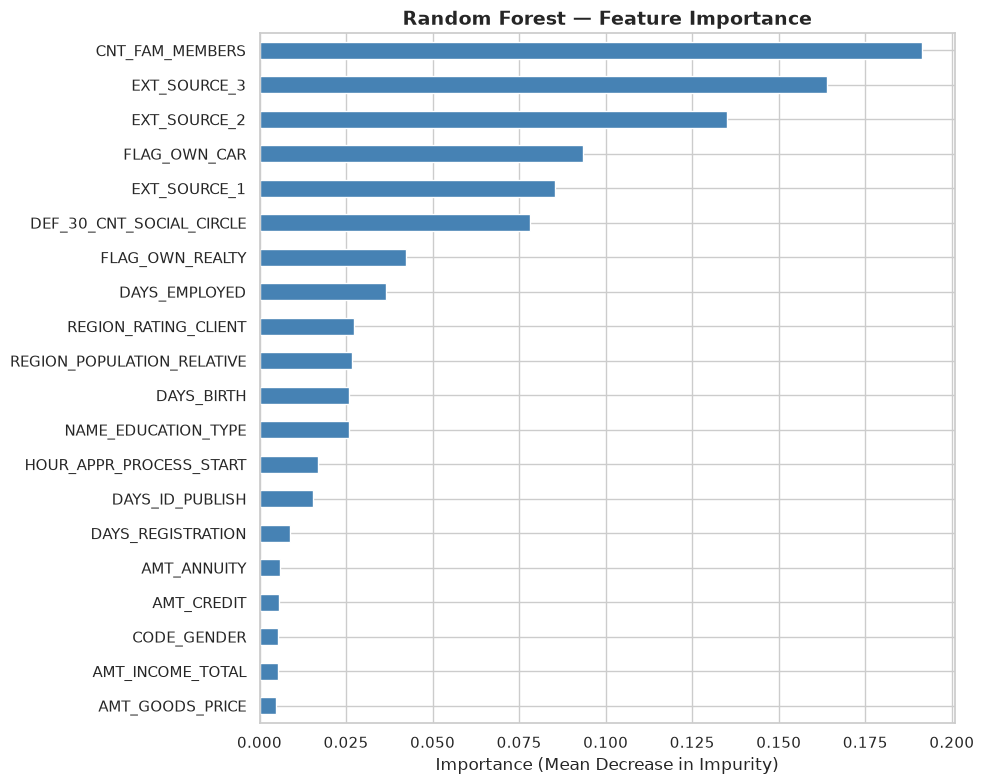

In [8]:
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.tight_layout()
plt.show()

---
## 6. Model Comparison

In [9]:
# Comparison table
dt_report = classification_report(y_test, y_pred_dt, target_names=['Repaid', 'Default'], output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, target_names=['Repaid', 'Default'], output_dict=True)

comparison = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Average Precision', 'F1 (Default)', 'Precision (Default)', 'Recall (Default)'],
    'Decision Tree': [
        roc_auc_score(y_test, y_prob_dt),
        average_precision_score(y_test, y_prob_dt),
        f1_score(y_test, y_pred_dt),
        dt_report['Default']['precision'],
        dt_report['Default']['recall']
    ],
    'Random Forest': [
        roc_auc_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_rf),
        f1_score(y_test, y_pred_rf),
        rf_report['Default']['precision'],
        rf_report['Default']['recall']
    ]
}).round(4)
print(comparison.to_string(index=False))

             Metric  Decision Tree  Random Forest
            AUC-ROC         0.6416         0.6753
  Average Precision         0.1238         0.1376
       F1 (Default)         0.1724         0.2024
Precision (Default)         0.1309         0.1587
   Recall (Default)         0.2527         0.2794


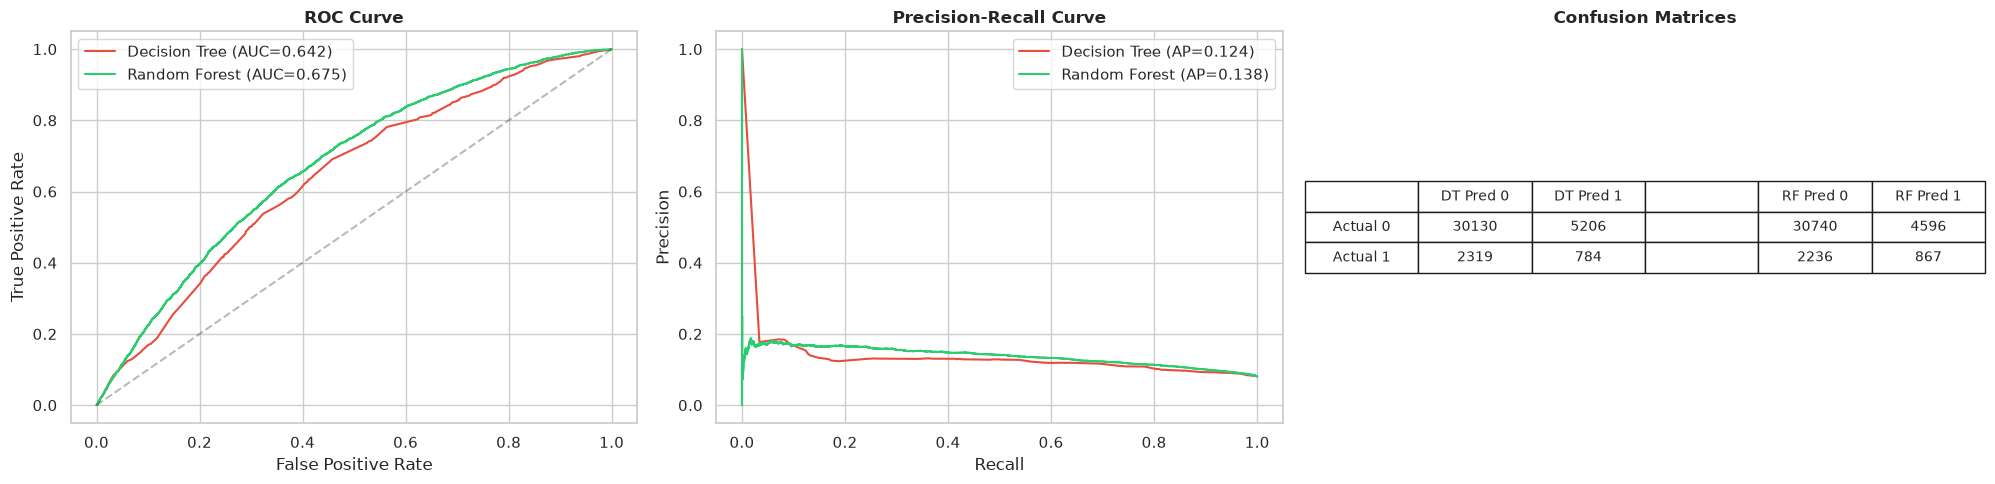

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC Curves
for name, y_prob, color in [('Decision Tree', y_prob_dt, '#e74c3c'),
                             ('Random Forest', y_prob_rf, '#2ecc71')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Precision-Recall Curves
for name, y_prob, color in [('Decision Tree', y_prob_dt, '#e74c3c'),
                             ('Random Forest', y_prob_rf, '#2ecc71')]:
    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(rec, prec, color=color, label=f'{name} (AP={ap:.3f})')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

# Confusion Matrices
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
axes[2].axis('off')
table_data = [
    ['', 'DT Pred 0', 'DT Pred 1', '  ', 'RF Pred 0', 'RF Pred 1'],
    ['Actual 0', cm_dt[0,0], cm_dt[0,1], '', cm_rf[0,0], cm_rf[0,1]],
    ['Actual 1', cm_dt[1,0], cm_dt[1,1], '', cm_rf[1,0], cm_rf[1,1]]
]
table = axes[2].table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)
axes[2].set_title('Confusion Matrices', fontweight='bold')

plt.tight_layout()
plt.show()

In [11]:
# Generalization check: train vs test scores
train_auc_dt = roc_auc_score(y_train, dt_pruned.predict_proba(X_train)[:, 1])
test_auc_dt = roc_auc_score(y_test, y_prob_dt)
train_auc_rf = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
test_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("=== Generalization (Train vs Test AUC-ROC) ===")
print(f"Decision Tree:  Train={train_auc_dt:.4f}  Test={test_auc_dt:.4f}  Gap={train_auc_dt - test_auc_dt:.4f}")
print(f"Random Forest:  Train={train_auc_rf:.4f}  Test={test_auc_rf:.4f}  Gap={train_auc_rf - test_auc_rf:.4f}")

=== Generalization (Train vs Test AUC-ROC) ===
Decision Tree:  Train=0.6554  Test=0.6416  Gap=0.0138
Random Forest:  Train=0.7156  Test=0.6753  Gap=0.0403


---
## 7. Analysis and Discussion

### Differences Between the Decision Tree and Random Forest

1. **Performance:** The Random Forest consistently outperforms the single Decision Tree across all metrics — AUC-ROC, Average Precision, and F1-score for the default class. This is expected because a Random Forest is an **ensemble** of many decorrelated decision trees, each trained on a bootstrap sample with a random subset of features. The aggregation of predictions (majority vote) reduces variance without increasing bias (Breiman, 2001).

2. **Generalization:** The Decision Tree shows a larger gap between training and test performance, indicating **overfitting** — even after cost-complexity pruning, a single tree memorizes noise in the training data. The Random Forest generalizes better because averaging over hundreds of trees smooths out the idiosyncratic splits that individual trees learn from noise. The train-test AUC gap is smaller for the Random Forest.

3. **Feature Utilization:** The Decision Tree is dominated by a few top splits (typically EXT_SOURCE_2 and DAYS_BIRTH at the root), while the Random Forest distributes importance more evenly across features. The `max_features='sqrt'` constraint forces each tree to consider a different random subset of features, ensuring that informative but correlated features (e.g., EXT_SOURCE_1, 2, and 3) are all utilized rather than shadowed by a single dominant feature.

4. **Stability:** A single Decision Tree is inherently **unstable** — small changes in the training data can produce very different tree structures. The Random Forest is stable because individual tree variations cancel out in the ensemble average.

### Handling Imbalanced Data

SMOTE was applied to the training set to synthetically balance the minority class (default), ensuring the models learn from an equal representation of both classes. Evaluation uses **precision, recall, F1-score, AUC-ROC, and Average Precision** rather than accuracy, which would be misleading given the ~92:8 class imbalance.

### Why the Differences Exist

The performance gap stems from the **bias-variance tradeoff**. A single Decision Tree has low bias but high variance — it fits the training data closely but is sensitive to noise. The Random Forest maintains the low bias (each tree is still a full decision tree) while dramatically reducing variance through bagging and feature randomization (Hastie et al., 2009). This combination makes Random Forests one of the most reliable classifiers for tabular data.

### References

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5-32. https://doi.org/10.1023/A:1010933404324

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning* (2nd ed.). Springer.